In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [2]:
df = pd.read_csv(r"C:\Users\asmis\OneDrive\Desktop\foodbridge\data\food_master_dataset.csv")

df.head()

,date,city,district,outlet_type,total_prepared_kg,total_sold_kg,surplus_kg,footfall_count,rainfall_mm,temperature_c,...,unemployment_rate,malnutrition_rate,literacy_rate,population_density,rainfall_category,temperature_category,surplus_category,feedback_source,feedback_text,sentiment_label
0,2024-04-12,Chennai,Mumbai Suburban,restaurant,234.27,178.91,55.36,936,33.819924,22.980879,...,9.281988,23.345097,71.159051,13857.50378,medium,cool,medium,logistics_team,Food supply was slightly different than expect...,neutral
1,2025-03-11,Chennai,Hyderabad,restaurant,216.43,169.38,47.05,611,57.927890,27.431975,...,5.543214,31.585074,57.331012,27642.76583,medium,moderate,medium,restaurant_staff,Coordination with volunteers worked great and ...,positive
2,2024-09-27,Chennai,Chennai,restaurant,222.05,135.79,86.26,1004,19.304584,25.671839,...,2.607615,37.821608,74.279447,22704.52683,low,moderate,medium,restaurant_staff,Food supply was slightly different than expect...,neutral
3,2024-04-16,Hyderabad,Chennai,restaurant,351.51,329.97,21.54,787,10.248639,27.042423,...,5.059368,15.320457,74.441768,19956.61007,low,moderate,low,logistics_team,Community support was excellent and food reach...,positive
4,2024-03-12,Bangalore,Hyderabad,supermarket,406.52,355.98,50.54,805,23.895929,24.664987,...,13.216180,8.737902,85.915223,14806.84788,medium,cool,medium,volunteer,Shelter operations were routine with no major ...,neutral


In [3]:
df[["feedback_text","sentiment_label"]].head()

,feedback_text,sentiment_label
0,Food supply was slightly different than expect...,neutral
1,Coordination with volunteers worked great and ...,positive
2,Food supply was slightly different than expect...,neutral
3,Community support was excellent and food reach...,positive
4,Shelter operations were routine with no major ...,neutral


In [4]:
print("Dataset size:", df.shape)

print(df["sentiment_label"].value_counts())

Dataset size: (10000, 27)
sentiment_label
positive    6374
neutral     3467
negative     159
Name: count, dtype: int64


In [5]:
print("Dataset size:", df.shape)
print(df["sentiment_label"].value_counts())

Dataset size: (10000, 27)
sentiment_label
positive    6374
neutral     3467
negative     159
Name: count, dtype: int64


In [6]:
print(df["sentiment_label"].unique())

['neutral' 'positive' 'negative']


In [7]:
df = df.dropna(subset=["feedback_text","sentiment_label"])

In [8]:
X = df["feedback_text"]

y = df["sentiment_label"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [12]:
pred = model.predict(X_test_vec)

In [13]:
print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        32
     neutral       1.00      1.00      1.00       693
    positive       1.00      1.00      1.00      1275

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [14]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Check duplicates between train and test
duplicates = set(X_train).intersection(set(X_test))

print("Duplicate texts between train and test:", len(duplicates))

Training samples: 8000
Testing samples: 2000
Duplicate texts between train and test: 15


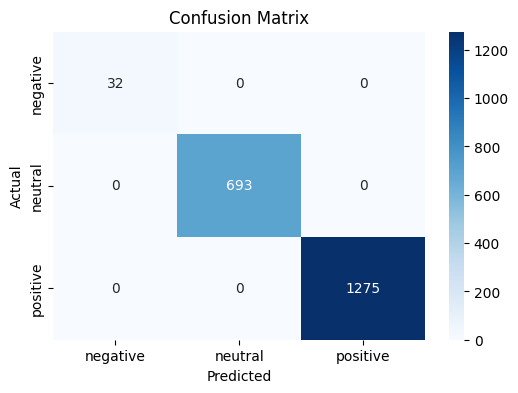

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_vec, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


Reason for high accuracy

The feedback dataset was synthetically generated with clear sentiment indicators (e.g., "fresh", "spoiled", "delayed"). These strong lexical signals allow TF-IDF based models to separate sentiment classes with very high accuracy.